## PHASE 6 — SYNTHETIC WIND VARIANCE SWAP (Tol 1997, θ=0 benchmark)
**Dataset B — SMARD Germany Electricity Market & ERA5 Wind, 2015–2024**

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

PHASE3_PATH = '../Phase_3/'
PHASE4_PATH = '../Phase_4/'
DATA_PATH   = '../../data/'
FIG_PATH    = '../../reference_tex/Plots/'

print('=' * 65)
print('  Phase 6 -- Synthetic Wind Variance Swap (Tol 1997, theta=0 benchmark)')
print('  Dataset B  |  Nordfriesland wind + SMARD Germany  |  2015-2024')
print('=' * 65)
print(f'  PHASE3_PATH : {PHASE3_PATH}')
print(f'  PHASE4_PATH : {PHASE4_PATH}')
print(f'  DATA_PATH   : {DATA_PATH}')
print(f'  FIG_PATH    : {FIG_PATH}')

  Phase 6 -- Synthetic Wind Variance Swap (Tol 1997, theta=0 benchmark)
  Dataset B  |  Nordfriesland wind + SMARD Germany  |  2015-2024
  PHASE3_PATH : ../Phase_3/
  PHASE4_PATH : ../Phase_4/
  DATA_PATH   : ../../data/
  FIG_PATH    : ../../reference_tex/Plots/


## 1. CONFIGURATION AND DATA LOADING

In [2]:
print('=' * 65)
print('  SECTION 1 -- CONFIGURATION AND DATA LOADING')
print('=' * 65)
print('')

gen1 = pd.read_csv(DATA_PATH + 'Actual_generation_1.csv', sep=';', encoding='utf-8-sig',
                    thousands=',', na_values=['-'])
gen2 = pd.read_csv(DATA_PATH + 'Actual_generation_2.csv', sep=';', encoding='utf-8-sig',
                    thousands=',', na_values=['-'])
pr1  = pd.read_csv(DATA_PATH + 'Day-ahead_prices_1.csv', sep=';', encoding='utf-8-sig',
                    thousands=',', na_values=['-'])
pr2  = pd.read_csv(DATA_PATH + 'Day-ahead_prices_2.csv', sep=';', encoding='utf-8-sig',
                    thousands=',', na_values=['-'])

h_series = pd.read_csv(PHASE3_PATH + 'garch_h_series_phase3.csv',
                        index_col=0, parse_dates=True)['h_t']
car4p    = pd.read_csv(PHASE4_PATH + 'car4_parameters_phase4.csv', index_col=0).squeeze()

DT_FMT = '%b %d, %Y %I:%M %p'
for df in (gen1, gen2, pr1, pr2):
    df['Start date'] = pd.to_datetime(df['Start date'], format=DT_FMT)

print(f'  {"File":<28} {"Rows":>8}   Date range')
for name, df in [
    ('Actual_generation_1.csv', gen1),
    ('Actual_generation_2.csv', gen2),
    ('Day-ahead_prices_1.csv',  pr1),
    ('Day-ahead_prices_2.csv',  pr2),
]:
    print(f'  {name:<28} {len(df):>8}   {df["Start date"].min().date()} -> {df["Start date"].max().date()}')
print(f'  {"garch_h_series_phase3.csv":<28} {len(h_series):>8}   {h_series.index.min().date()} -> {h_series.index.max().date()}')
print('')
print(f'  Phase 4 parameters loaded: C0 = {float(car4p["C0"]):.6f}, h_t0 = {float(car4p["h_t0"]):.6f}')

  SECTION 1 -- CONFIGURATION AND DATA LOADING



  File                             Rows   Date range
  Actual_generation_1.csv         52608   2015-01-01 -> 2020-12-31
  Actual_generation_2.csv         35064   2021-01-01 -> 2024-12-31
  Day-ahead_prices_1.csv          26304   2015-01-01 -> 2017-12-31
  Day-ahead_prices_2.csv          61368   2018-01-01 -> 2024-12-31
  garch_h_series_phase3.csv        3653   2015-01-01 -> 2024-12-31

  Phase 4 parameters loaded: C0 = 1.162775, h_t0 = 0.751100


## 2. SMARD WIND GENERATION — DAILY SERIES

In [3]:
print('=' * 65)
print('  SECTION 2 -- SMARD WIND GENERATION (DAILY)')
print('=' * 65)
print('')

GEN_COL = 'Wind onshore [MWh] Calculated resolutions'
gen = pd.concat([gen1[['Start date', GEN_COL]], gen2[['Start date', GEN_COL]]], ignore_index=True)
gen = gen.sort_values('Start date').drop_duplicates('Start date').reset_index(drop=True)
gen['date'] = gen['Start date'].dt.date

gen_daily = gen.groupby('date').agg(
    G_daily_MWh=(GEN_COL, 'sum'),
    n_obs=(GEN_COL, 'count'),
)
gen_daily['n_total'] = gen.groupby('date').size()
gen_daily['frac_missing'] = 1.0 - gen_daily['n_obs'] / gen_daily['n_total']
n_before = len(gen_daily)
gen_daily = gen_daily.loc[gen_daily['frac_missing'] <= 0.20, ['G_daily_MWh']]
gen_daily.index = pd.to_datetime(gen_daily.index)
gen_daily.index.name = 'date'
n_after = len(gen_daily)

print(f'  Hourly observations loaded : {len(gen):,}')
print(f'  Daily obs before filter    : {n_before:,}')
print(f'  Daily obs after filter     : {n_after:,}  (dropped {n_before - n_after} days >20% missing)')
print(f'  NaN count in G_daily_MWh   : {gen_daily["G_daily_MWh"].isnull().sum()}')
print(f'  Mean G_daily_MWh           : {gen_daily["G_daily_MWh"].mean():,.1f}')
print(f'  Std  G_daily_MWh           : {gen_daily["G_daily_MWh"].std():,.1f}')
print(f'  Date range                 : {gen_daily.index.min().date()} -> {gen_daily.index.max().date()}')

  SECTION 2 -- SMARD WIND GENERATION (DAILY)

  Hourly observations loaded : 87,662
  Daily obs before filter    : 3,653
  Daily obs after filter     : 3,653  (dropped 0 days >20% missing)
  NaN count in G_daily_MWh   : 0
  Mean G_daily_MWh           : 255,560.2
  Std  G_daily_MWh           : 196,107.1
  Date range                 : 2015-01-01 -> 2024-12-31


## 3. DAY-AHEAD ELECTRICITY PRICES — DAILY SERIES

  SECTION 3 -- DAY-AHEAD ELECTRICITY PRICES (DAILY)

  Hourly observations loaded : 87,662
  Daily obs before filter    : 3,653
  Daily obs after filter     : 3,649  (dropped 4 days >20% missing)
  Mean price_EUR_MWh         : 71.38
  Std  price_EUR_MWh         : 78.05
  Aligned G/P sample         : 3,649 days  (2015-01-05 -> 2024-12-31)


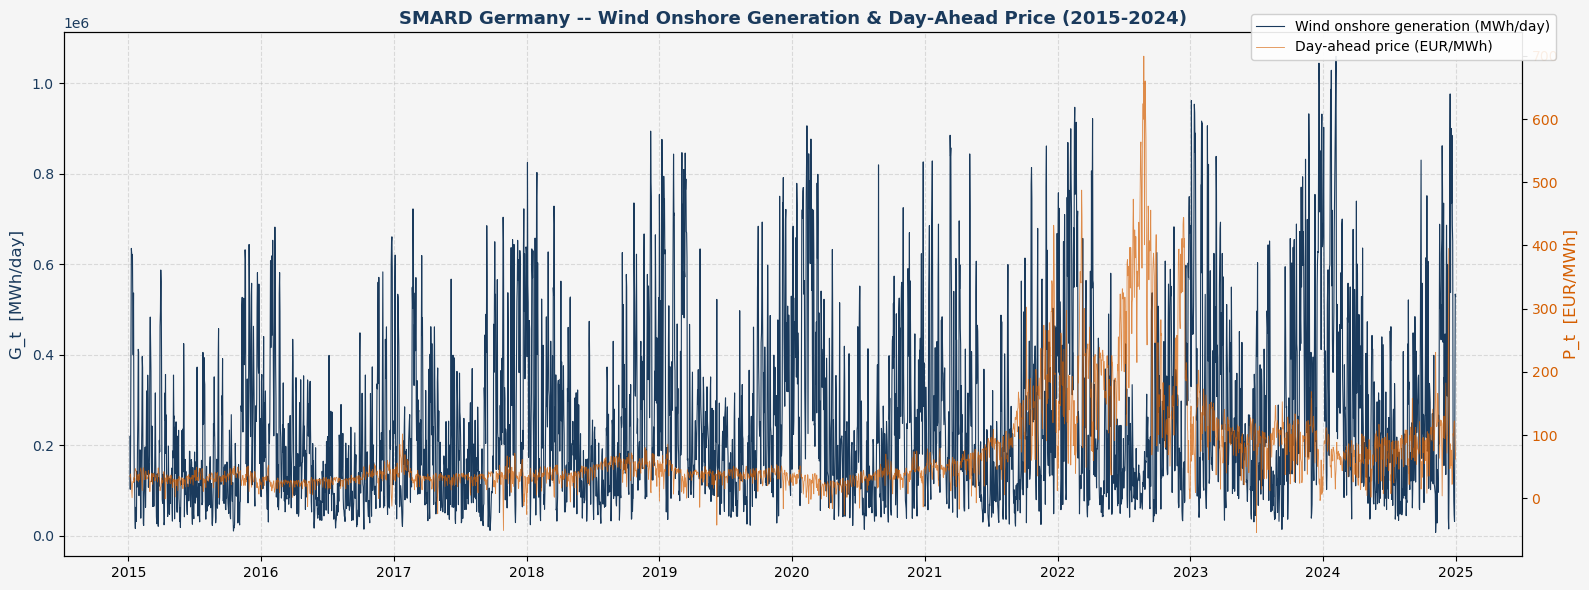

Figure saved -> ../../reference_tex/Plots/phase6_B_smard_overview.png


In [4]:
print('=' * 65)
print('  SECTION 3 -- DAY-AHEAD ELECTRICITY PRICES (DAILY)')
print('=' * 65)
print('')

DE_LU_COL = 'Germany/Luxembourg [€/MWh] Calculated resolutions'
DE_AT_COL = 'DE/AT/LU [€/MWh] Calculated resolutions'

pr = pd.concat([pr1[['Start date', DE_LU_COL, DE_AT_COL]],
                pr2[['Start date', DE_LU_COL, DE_AT_COL]]], ignore_index=True)
pr = pr.sort_values('Start date').drop_duplicates('Start date').reset_index(drop=True)
pr['price'] = pr[DE_LU_COL].combine_first(pr[DE_AT_COL])
pr['date'] = pr['Start date'].dt.date

price_daily = pr.groupby('date').agg(
    price_EUR_MWh=('price', 'mean'),
    n_obs=('price', 'count'),
)
price_daily['n_total'] = pr.groupby('date').size()
price_daily['frac_missing'] = 1.0 - price_daily['n_obs'] / price_daily['n_total']
n_before = len(price_daily)
price_daily = price_daily.loc[price_daily['frac_missing'] <= 0.20, ['price_EUR_MWh']]
price_daily.index = pd.to_datetime(price_daily.index)
price_daily.index.name = 'date'
n_after = len(price_daily)

print(f'  Hourly observations loaded : {len(pr):,}')
print(f'  Daily obs before filter    : {n_before:,}')
print(f'  Daily obs after filter     : {n_after:,}  (dropped {n_before - n_after} days >20% missing)')
print(f'  Mean price_EUR_MWh         : {price_daily["price_EUR_MWh"].mean():.2f}')
print(f'  Std  price_EUR_MWh         : {price_daily["price_EUR_MWh"].std():.2f}')

smard = gen_daily.join(price_daily, how='inner')
print(f'  Aligned G/P sample         : {len(smard):,} days  ({smard.index.min().date()} -> {smard.index.max().date()})')

darkblue, orange, lightgray = '#1a3a5c', '#d55e00', '#f5f5f5'
fig, ax1 = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(lightgray); ax1.set_facecolor(lightgray)
ax1.plot(smard.index, smard['G_daily_MWh'], color=darkblue, lw=0.8, label='Wind onshore generation (MWh/day)')
ax1.set_ylabel('G_t  [MWh/day]', color=darkblue, fontsize=12)
ax1.tick_params(axis='y', labelcolor=darkblue)
ax2 = ax1.twinx()
ax2.plot(smard.index, smard['price_EUR_MWh'], color=orange, lw=0.6, alpha=0.7, label='Day-ahead price (EUR/MWh)')
ax2.set_ylabel('P_t  [EUR/MWh]', color=orange, fontsize=12)
ax2.tick_params(axis='y', labelcolor=orange)
ax1.set_title('SMARD Germany -- Wind Onshore Generation & Day-Ahead Price (2015-2024)',
              fontsize=13, color=darkblue, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)
fig.legend(loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_B_smard_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {FIG_PATH}phase6_B_smard_overview.png')

## 4. LOG-RETURNS AND REALISED VARIANCE (TRACK A)

  SECTION 4 -- LOG-RETURNS AND REALISED VARIANCE (TRACK A)

  Valid log-return obs : 3,648 / 3,649
  Mean RV_daily         : 0.458271
  K_var^A (full-sample mean of rolling 252d) : 113.144944

  Seasonal mean RV_daily:
    DJF : 0.400765
    MAM : 0.457876
    JJA : 0.473479
    SON : 0.500043


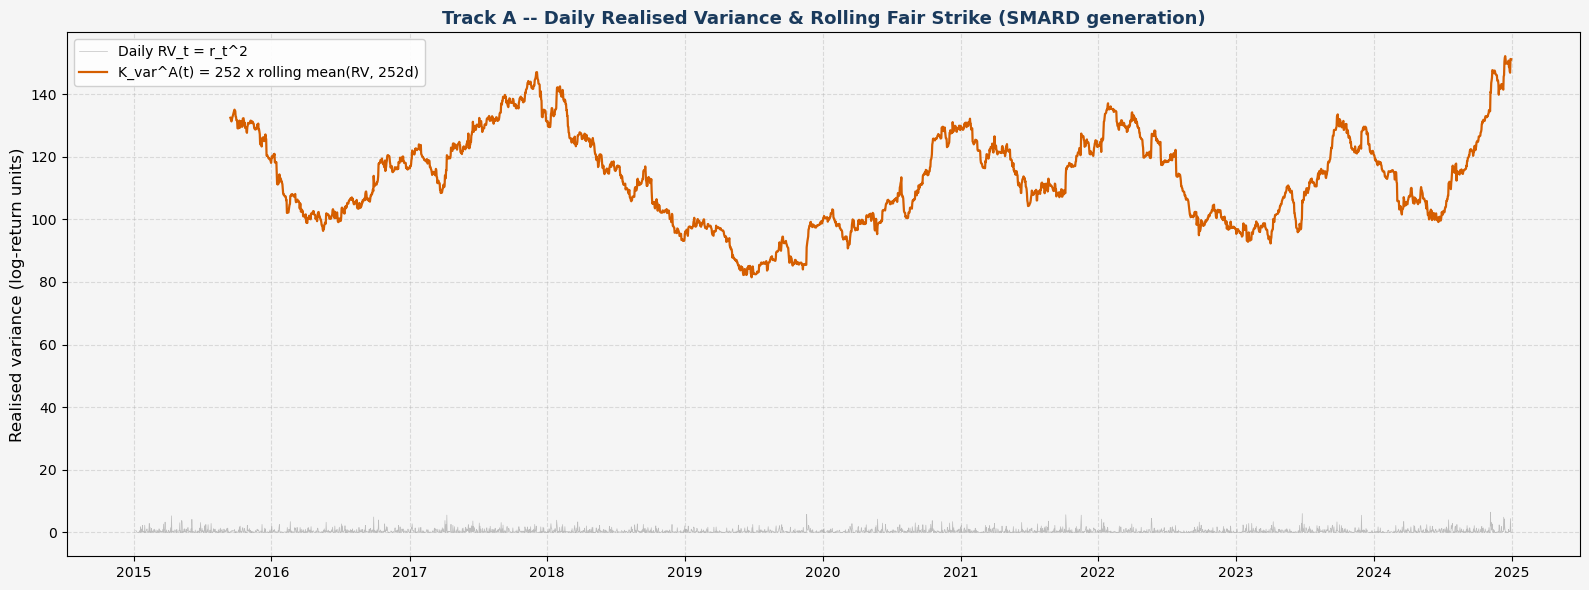

Figure saved -> ../../reference_tex/Plots/phase6_B_rv_tracka.png


In [5]:
print('=' * 65)
print('  SECTION 4 -- LOG-RETURNS AND REALISED VARIANCE (TRACK A)')
print('=' * 65)
print('')

G = smard['G_daily_MWh']
log_ret = np.log(G / G.shift(1))
log_ret = log_ret.where((G > 0) & (G.shift(1) > 0))
RV = log_ret ** 2
K_varA_rolling = 252.0 * RV.rolling(252, min_periods=252).mean()

smard['log_return_G']  = log_ret
smard['RV_daily']      = RV
smard['RV_rolling252'] = K_varA_rolling

K_varA_mean = float(K_varA_rolling.mean())

print(f'  Valid log-return obs : {log_ret.notna().sum():,} / {len(G):,}')
print(f'  Mean RV_daily         : {RV.mean():.6f}')
print(f'  K_var^A (full-sample mean of rolling 252d) : {K_varA_mean:.6f}')
print('')

season_map = {12: 'DJF', 1: 'DJF', 2: 'DJF', 3: 'MAM', 4: 'MAM', 5: 'MAM',
              6: 'JJA', 7: 'JJA', 8: 'JJA', 9: 'SON', 10: 'SON', 11: 'SON'}
season = pd.Series(smard.index.month, index=smard.index).map(season_map)
print('  Seasonal mean RV_daily:')
for s in ['DJF', 'MAM', 'JJA', 'SON']:
    print(f'    {s} : {RV[season == s].mean():.6f}')

darkblue, orange, lightgray = '#1a3a5c', '#d55e00', '#f5f5f5'
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(lightgray); ax.set_facecolor(lightgray)
ax.plot(smard.index, RV, color='#999999', lw=0.5, alpha=0.6, label='Daily RV_t = r_t^2')
ax.plot(smard.index, K_varA_rolling, color=orange, lw=1.6, label='K_var^A(t) = 252 x rolling mean(RV, 252d)')
ax.set_ylabel('Realised variance (log-return units)', fontsize=12)
ax.set_title('Track A -- Daily Realised Variance & Rolling Fair Strike (SMARD generation)',
             fontsize=13, color=darkblue, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_B_rv_tracka.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {FIG_PATH}phase6_B_rv_tracka.png')

## 5. MODEL-IMPLIED FAIR STRIKE (TRACK B)

In [6]:
print('=' * 65)
print('  SECTION 5a -- STATIC SCENARIOS: K_var^B(h) = h x C0')
print('=' * 65)
print('')

C0   = float(car4p['C0'])
h_t0 = float(car4p['h_t0'])

h_season = pd.Series(h_series.index.month, index=h_series.index).map(season_map)
h_winter = float(h_series[h_season == 'DJF'].mean())
h_summer = float(h_series[h_season == 'JJA'].mean())
h_one    = 1.0

scenarios = {'h_t0': h_t0, 'h_winter': h_winter, 'h_summer': h_summer, 'h=1.0': h_one}

print(f'  C0 (Fourier, Phase 4)            = {C0:.6f}')
print(f'  h_t0    (end-of-sample GARCH h)  = {h_t0:.6f}')
print(f'  h_winter (DJF mean)              = {h_winter:.6f}')
print(f'  h_summer (JJA mean)              = {h_summer:.6f}')
print('')
print(f'  {"Scenario":<10} {"h":>10} {"K_var^B = h*C0":>16}')
for name, h in scenarios.items():
    print(f'  {name:<10} {h:>10.6f} {h * C0:>16.6f}')
print('')
print(f'  K_var^A (Track A, full-sample mean) = {K_varA_mean:.6f}')
print('  NOTE: K_var^B is in W_tilde (wind-speed residual) variance units;')
print('  K_var^A is in log-return-of-generation units. Direct comparison requires')
print('  the unit reconciliation in Section 5b (power-curve delta method).')

  SECTION 5a -- STATIC SCENARIOS: K_var^B(h) = h x C0

  C0 (Fourier, Phase 4)            = 1.162775
  h_t0    (end-of-sample GARCH h)  = 0.751100
  h_winter (DJF mean)              = 0.738415
  h_summer (JJA mean)              = 0.766003

  Scenario            h   K_var^B = h*C0
  h_t0         0.751100         0.873361
  h_winter     0.738415         0.858610
  h_summer     0.766003         0.890689
  h=1.0        1.000000         1.162775

  K_var^A (Track A, full-sample mean) = 113.144944
  NOTE: K_var^B is in W_tilde (wind-speed residual) variance units;
  K_var^A is in log-return-of-generation units. Direct comparison requires
  the unit reconciliation in Section 5b (power-curve delta method).


In [7]:
print('=' * 65)
print('  SECTION 5b -- UNIT RECONCILIATION (DELTA METHOD)')
print('=' * 65)
print('')

wind_raw = pd.read_csv(DATA_PATH + 'germany_wind.csv', skiprows=2, parse_dates=['time'])
wind_raw['_date'] = wind_raw['time'].dt.date
wind_daily = wind_raw.groupby('_date')['wind_speed_100m (m/s)'].mean()
wind_daily.index = pd.to_datetime(wind_daily.index)

W_bar = float(wind_daily.mean())
delta_factor = 9.0 / W_bar ** 2

print(f'  W_bar (mean wind_speed_100m, 2015-2024 daily) = {W_bar:.4f} m/s')
print(f'  Delta-method factor 9/W_bar^2                  = {delta_factor:.6f}')
print('')
print(f'  {"Scenario":<10} {"K_var^B":>12} {"K_var^B_scaled":>16}')
K_varB_scaled = {}
for name, h in scenarios.items():
    raw = h * C0
    scl = delta_factor * h * C0
    K_varB_scaled[name] = scl
    print(f'  {name:<10} {raw:>12.6f} {scl:>16.6f}')
print('')
print(f'  K_var^A (Track A)                = {K_varA_mean:.6f}')
print(f'  dist_A = |K_var^A - K_varB_scaled(h_t0)| = {abs(K_varA_mean - K_varB_scaled["h_t0"]):.6f}')

  SECTION 5b -- UNIT RECONCILIATION (DELTA METHOD)

  W_bar (mean wind_speed_100m, 2015-2024 daily) = 8.0682 m/s
  Delta-method factor 9/W_bar^2                  = 0.138259

  Scenario        K_var^B   K_var^B_scaled
  h_t0           0.873361         0.120750
  h_winter       0.858610         0.118710
  h_summer       0.890689         0.123145
  h=1.0          1.162775         0.160764

  K_var^A (Track A)                = 113.144944
  dist_A = |K_var^A - K_varB_scaled(h_t0)| = 113.024194


In [8]:
print('=' * 65)
print('  SECTION 5c -- TIME-VARYING TRACK B & RMSE vs TRACK A')
print('=' * 65)
print('')

K_varB_rolling        = h_series * C0
K_varB_scaled_rolling = delta_factor * h_series * C0

aligned = pd.concat([
    smard['RV_rolling252'].rename('K_varA_rolling'),
    K_varB_scaled_rolling.rename('K_varB_scaled_rolling'),
], axis=1).dropna()

rmse_5c = float(np.sqrt(np.mean((aligned['K_varA_rolling'] - aligned['K_varB_scaled_rolling']) ** 2)))

print(f'  Overlapping obs (both series non-NaN) : {len(aligned):,}')
print(f'  RMSE(K_var^A_rolling, K_var^B_scaled_rolling) = {rmse_5c:.6f}')
print('  This is the empirical distance between the empirical (Track A) and')
print('  model-implied (Track B, unit-reconciled) fair-strike processes.')

  SECTION 5c -- TIME-VARYING TRACK B & RMSE vs TRACK A

  Overlapping obs (both series non-NaN) : 3,397
  RMSE(K_var^A_rolling, K_var^B_scaled_rolling) = 113.953139
  This is the empirical distance between the empirical (Track A) and
  model-implied (Track B, unit-reconciled) fair-strike processes.


In [9]:
print('=' * 65)
print('  SECTION 5d -- OUT-OF-TIME VALIDATION (FULL-SAMPLE MODEL -> 2020-2024)')
print('=' * 65)
print('')

OOS_START = pd.Timestamp('2020-01-01')

print('  Uses the FULL-SAMPLE K_var^B_scaled(h_t0) (calibrated on 2015-2024,')
print('  Section 5a/5b) as a fixed model prediction; no re-estimation of C0 or')
print('  h_t0 on a restricted window. This tests out-of-time predictive content')
print('  under fixed parameters, not genuine out-of-sample calibration.')
print('')
print(f'  K_var^B_scaled(h_t0), full-sample fixed = {K_varB_scaled["h_t0"]:.6f}')

oos_actual = smard.loc[smard.index >= OOS_START, 'RV_rolling252'].dropna()
rmse_oos = float(np.sqrt(np.mean((oos_actual - K_varB_scaled['h_t0']) ** 2)))

print(f'  Hold-out window : {OOS_START.date()} -> {smard.index.max().date()}')
print(f'  Hold-out obs (K_var^A_rolling, non-NaN) : {len(oos_actual):,}')
print(f'  Out-of-time RMSE(K_var^B_scaled(h_t0), K_var^A) = {rmse_oos:.6f}')

  SECTION 5d -- OUT-OF-TIME VALIDATION (FULL-SAMPLE MODEL -> 2020-2024)

  Uses the FULL-SAMPLE K_var^B_scaled(h_t0) (calibrated on 2015-2024,
  Section 5a/5b) as a fixed model prediction; no re-estimation of C0 or
  h_t0 on a restricted window. This tests out-of-time predictive content
  under fixed parameters, not genuine out-of-sample calibration.

  K_var^B_scaled(h_t0), full-sample fixed = 0.120750
  Hold-out window : 2020-01-01 -> 2024-12-31
  Hold-out obs (K_var^A_rolling, non-NaN) : 1,827
  Out-of-time RMSE(K_var^B_scaled(h_t0), K_var^A) = 114.569461


## 6. POWER CURVE LINKAGE

  SECTION 6 -- POWER CURVE LINKAGE

  Aligned obs (G_t, W_t)         : 3,649
  OLS:  G_t = c * W_t^3 + b
    c (slope)      = 155.120785
    b (intercept)  = 132004.58
    R^2            = 0.5871

  Delta-method factor 9/W_bar^2  = 0.138259   (Section 5b)
  c and 9/W_bar^2 are not directly comparable in level (different units/
  normalisation) but both summarise the same cubic wind-to-power linkage;
  R^2 confirms a meaningful empirical relationship at hub height.


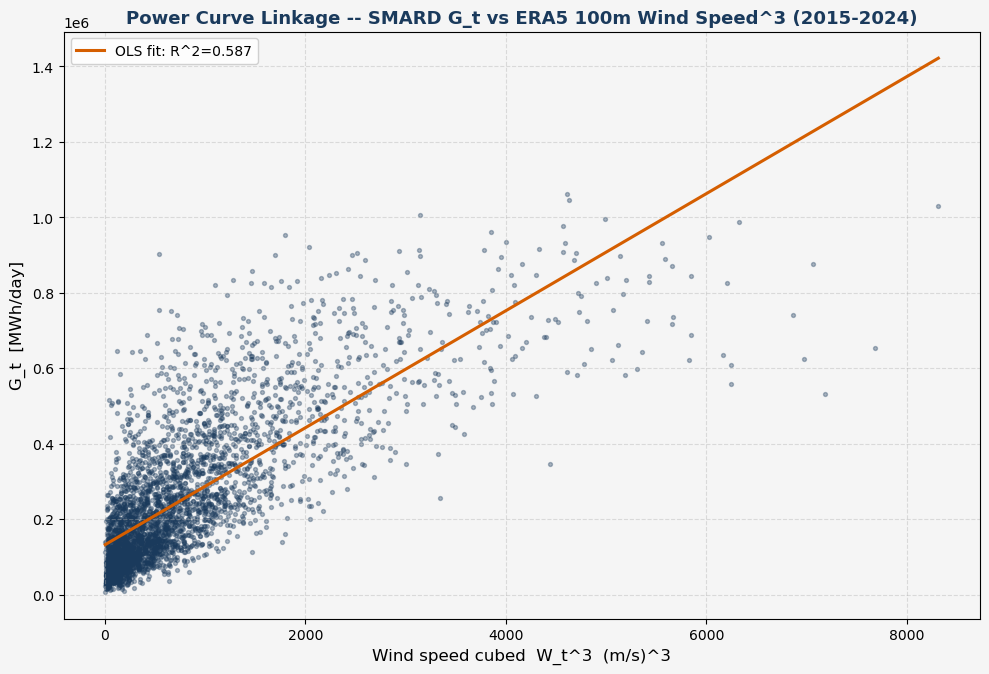

Figure saved -> ../../reference_tex/Plots/phase6_B_power_curve.png


In [10]:
print('=' * 65)
print('  SECTION 6 -- POWER CURVE LINKAGE')
print('=' * 65)
print('')

pc = pd.concat([smard['G_daily_MWh'], wind_daily.rename('wind_speed_100m')], axis=1).dropna()
pc['W3'] = pc['wind_speed_100m'] ** 3

slope, intercept, r_value, p_value, std_err = stats.linregress(pc['W3'], pc['G_daily_MWh'])
r2 = r_value ** 2

print(f'  Aligned obs (G_t, W_t)         : {len(pc):,}')
print(f'  OLS:  G_t = c * W_t^3 + b')
print(f'    c (slope)      = {slope:.6f}')
print(f'    b (intercept)  = {intercept:.2f}')
print(f'    R^2            = {r2:.4f}')
print('')
print(f'  Delta-method factor 9/W_bar^2  = {delta_factor:.6f}   (Section 5b)')
print('  c and 9/W_bar^2 are not directly comparable in level (different units/')
print('  normalisation) but both summarise the same cubic wind-to-power linkage;')
print('  R^2 confirms a meaningful empirical relationship at hub height.')

darkblue, orange, lightgray = '#1a3a5c', '#d55e00', '#f5f5f5'
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(lightgray); ax.set_facecolor(lightgray)
ax.scatter(pc['W3'], pc['G_daily_MWh'], s=8, color=darkblue, alpha=0.35)
xx = np.linspace(pc['W3'].min(), pc['W3'].max(), 100)
ax.plot(xx, slope * xx + intercept, color=orange, lw=2.2,
        label=f'OLS fit: R^2={r2:.3f}')
ax.set_xlabel('Wind speed cubed  W_t^3  (m/s)^3', fontsize=12)
ax.set_ylabel('G_t  [MWh/day]', fontsize=12)
ax.set_title('Power Curve Linkage -- SMARD G_t vs ERA5 100m Wind Speed^3 (2015-2024)',
             fontsize=13, color=darkblue, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_B_power_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {FIG_PATH}phase6_B_power_curve.png')

## 7. MERIT-ORDER EFFECT

  SECTION 7 -- MERIT-ORDER EFFECT

  Full-sample Pearson rho(G, P)  = -0.1616
  rho_pre  (< 2018-10-01)        = -0.4759
  rho_post (>= 2018-10-01)       = -0.2745
  Both sub-periods show the expected negative sign (high wind -> low price);
  the magnitude difference likely reflects growing renewables capacity and
  market conditions over the sample, not an artefact of the price-zone split.


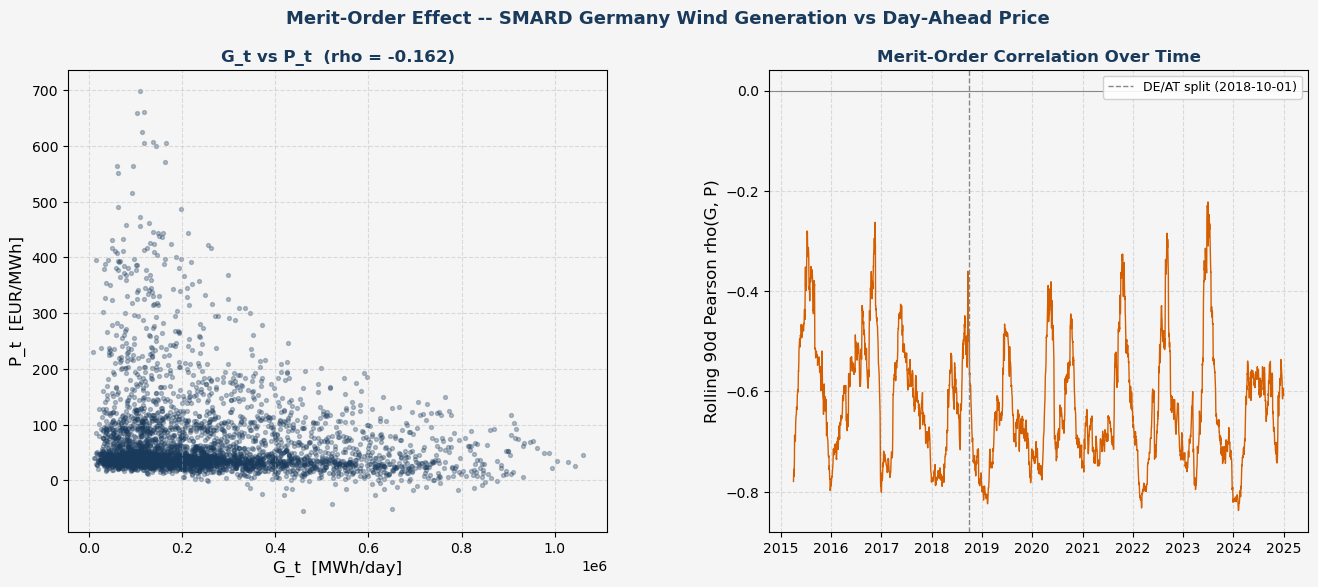

Figure saved -> ../../reference_tex/Plots/phase6_B_merit_order.png


In [11]:
print('=' * 65)
print('  SECTION 7 -- MERIT-ORDER EFFECT')
print('=' * 65)
print('')

rho_full = smard['G_daily_MWh'].corr(smard['price_EUR_MWh'])
rho_roll = smard['G_daily_MWh'].rolling(90).corr(smard['price_EUR_MWh'])

split = pd.Timestamp('2018-10-01')
rho_pre  = smard.loc[smard.index <  split, ['G_daily_MWh', 'price_EUR_MWh']].corr().iloc[0, 1]
rho_post = smard.loc[smard.index >= split, ['G_daily_MWh', 'price_EUR_MWh']].corr().iloc[0, 1]

print(f'  Full-sample Pearson rho(G, P)  = {rho_full:.4f}')
print(f'  rho_pre  (< 2018-10-01)        = {rho_pre:.4f}')
print(f'  rho_post (>= 2018-10-01)       = {rho_post:.4f}')
print('  Both sub-periods show the expected negative sign (high wind -> low price);')
print('  the magnitude difference likely reflects growing renewables capacity and')
print('  market conditions over the sample, not an artefact of the price-zone split.')

darkblue, orange, lightgray = '#1a3a5c', '#d55e00', '#f5f5f5'
fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor(lightgray)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.30)

ax0 = fig.add_subplot(gs[0, 0]); ax0.set_facecolor(lightgray)
ax0.scatter(smard['G_daily_MWh'], smard['price_EUR_MWh'], s=8, color=darkblue, alpha=0.3)
ax0.set_xlabel('G_t  [MWh/day]', fontsize=12)
ax0.set_ylabel('P_t  [EUR/MWh]', fontsize=12)
ax0.set_title(f'G_t vs P_t  (rho = {rho_full:.3f})', fontsize=12, color=darkblue, fontweight='bold')
ax0.grid(True, linestyle='--', alpha=0.4)

ax1 = fig.add_subplot(gs[0, 1]); ax1.set_facecolor(lightgray)
ax1.plot(smard.index, rho_roll, color=orange, lw=1.0)
ax1.axhline(0, color='#888888', lw=0.8)
ax1.axvline(split, color='#888888', lw=1.0, ls='--', label='DE/AT split (2018-10-01)')
ax1.set_ylabel('Rolling 90d Pearson rho(G, P)', fontsize=12)
ax1.set_title('Merit-Order Correlation Over Time', fontsize=12, color=darkblue, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Merit-Order Effect -- SMARD Germany Wind Generation vs Day-Ahead Price',
             fontsize=13, color=darkblue, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_B_merit_order.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {FIG_PATH}phase6_B_merit_order.png')

## 8. SYNTHETIC VARIANCE SWAP — PAYOFF SIMULATION

  SECTION 8 -- SYNTHETIC VARIANCE SWAP: PAYOFF SIMULATION

    Year  RV_annual   Payoff_A     PayoffB_h_t0 PayoffB_h_winter PayoffB_h_summer    PayoffB_h=1.0
    2015 121.623951   8.479007       121.503202       121.505241       121.500806       121.463188
    2016 113.230109   0.085165       113.109359       113.111398       113.106963       113.069345
    2017 129.171573  16.026629       129.050824       129.052863       129.048428       129.010810
    2018 106.160792  -6.984152       106.040042       106.042081       106.037646       106.000028
    2019  95.486975 -17.657969        95.366225        95.368265        95.363830        95.326211
    2020 116.743668   3.598724       116.622919       116.624958       116.620523       116.582905
    2021 118.967503   5.822559       118.846753       118.848793       118.844358       118.806739
    2022 101.796172 -11.348773       101.675422       101.677461       101.673026       101.635408
    2023 119.706670   6.561726       119.585920   

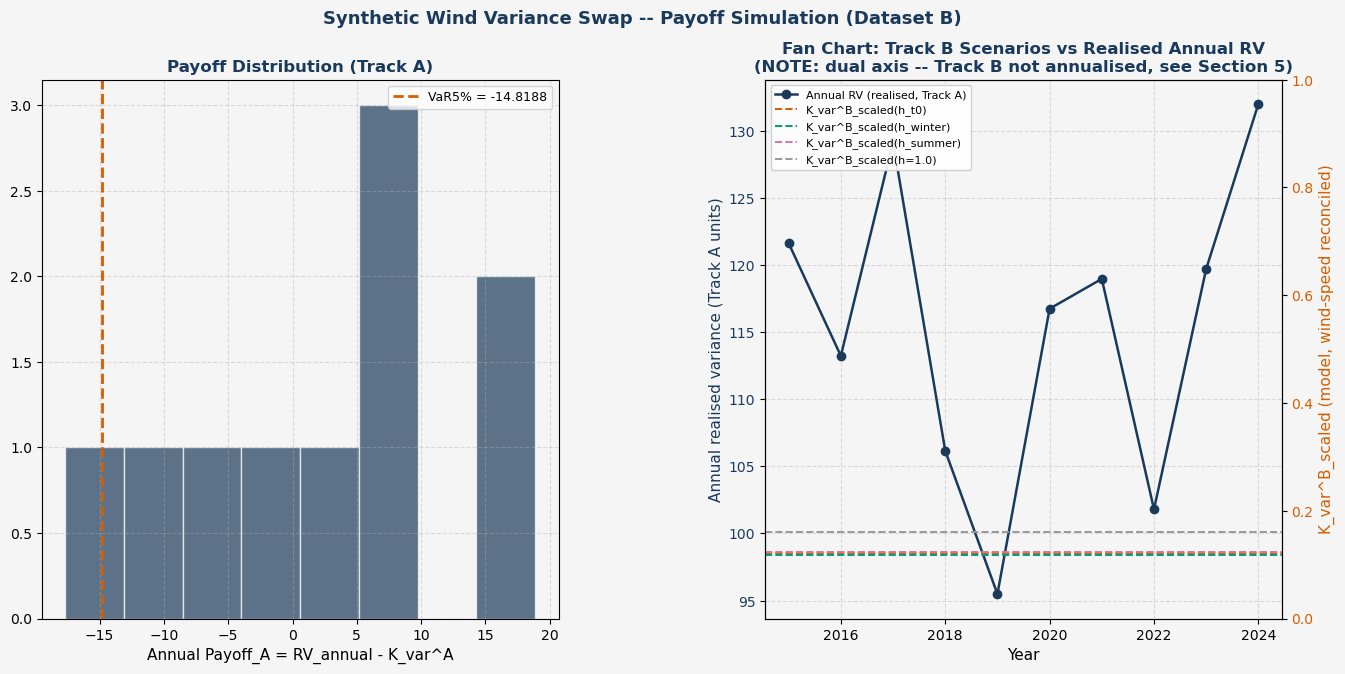

Figure saved -> ../../reference_tex/Plots/phase6_B_payoff_fan.png


In [12]:
print('=' * 65)
print('  SECTION 8 -- SYNTHETIC VARIANCE SWAP: PAYOFF SIMULATION')
print('=' * 65)
print('')

annual_RV = 252.0 * smard['RV_daily'].groupby(smard.index.year).mean()
years = annual_RV.index.values

payoff_A = annual_RV - K_varA_mean
payoff_B = {name: annual_RV - K_varB_scaled[name] for name in scenarios}

print(f'  {"Year":>6} {"RV_annual":>10} {"Payoff_A":>10}', end='')
for name in scenarios:
    print(f' {("PayoffB_" + name):>16}', end='')
print('')
for y in years:
    print(f'  {y:>6} {annual_RV[y]:>10.6f} {payoff_A[y]:>10.6f}', end='')
    for name in scenarios:
        print(f' {payoff_B[name][y]:>16.6f}', end='')
    print('')

var5_A = float(np.percentile(payoff_A, 5))
print('')
print(f'  Payoff_A:  mean = {payoff_A.mean():.6f}  std = {payoff_A.std():.6f}  VaR5% = {var5_A:.6f}')

darkblue, orange, lightgray = '#1a3a5c', '#d55e00', '#f5f5f5'
fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor(lightgray)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.40)

ax0 = fig.add_subplot(gs[0, 0]); ax0.set_facecolor(lightgray)
ax0.hist(payoff_A, bins=8, color=darkblue, alpha=0.7, edgecolor='white')
ax0.axvline(var5_A, color=orange, lw=2, ls='--', label=f'VaR5% = {var5_A:.4f}')
ax0.set_xlabel('Annual Payoff_A = RV_annual - K_var^A', fontsize=11)
ax0.set_title('Payoff Distribution (Track A)', fontsize=12, color=darkblue, fontweight='bold')
ax0.legend(fontsize=9)
ax0.grid(True, linestyle='--', alpha=0.4)

ax1 = fig.add_subplot(gs[0, 1]); ax1.set_facecolor(lightgray)
l1, = ax1.plot(years, annual_RV, color=darkblue, lw=1.8, marker='o', label='Annual RV (realised, Track A)')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Annual realised variance (Track A units)', color=darkblue, fontsize=11)
ax1.tick_params(axis='y', labelcolor=darkblue)

ax1b = ax1.twinx()
colors_fan = ['#d55e00', '#009e73', '#cc79a7', '#999999']
fan_lines = [l1]
for (name, _), col in zip(scenarios.items(), colors_fan):
    fl = ax1b.axhline(K_varB_scaled[name], color=col, lw=1.4, ls='--', label=f'K_var^B_scaled({name})')
    fan_lines.append(fl)
ax1b.set_ylabel('K_var^B_scaled (model, wind-speed reconciled)', color=orange, fontsize=11)
ax1b.tick_params(axis='y', labelcolor=orange)

ax1.set_title('Fan Chart: Track B Scenarios vs Realised Annual RV\n(NOTE: dual axis -- Track B not annualised, see Section 5)',
              fontsize=12, color=darkblue, fontweight='bold')
ax1.legend(handles=fan_lines, fontsize=8, framealpha=0.9, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Synthetic Wind Variance Swap -- Payoff Simulation (Dataset B)',
             fontsize=13, color=darkblue, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_B_payoff_fan.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {FIG_PATH}phase6_B_payoff_fan.png')

## 9. COMPLETE SUMMARY TABLE

In [13]:
print('=' * 65)
print('  SECTION 9 -- COMPLETE SUMMARY TABLE')
print('=' * 65)
print('')

rows = []
rows.append({
    'series': 'Track_A', 'K_var': K_varA_mean,
    'payoff_mean': float(payoff_A.mean()), 'payoff_std': float(payoff_A.std()),
    'VaR5pct': var5_A,
})
for name in scenarios:
    p = payoff_B[name]
    rows.append({
        'series': f'Track_B_{name}', 'K_var': K_varB_scaled[name],
        'payoff_mean': float(p.mean()), 'payoff_std': float(p.std()),
        'VaR5pct': float(np.percentile(p, 5)),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

summary_df.to_csv('variance_swap_summary_phase6.csv', index=False)
print('')
print('Saved -> variance_swap_summary_phase6.csv')

  SECTION 9 -- COMPLETE SUMMARY TABLE

          series      K_var  payoff_mean  payoff_std    VaR5pct
         Track_A 113.144944     2.343442   11.587837 -14.818831
    Track_B_h_t0   0.120750   115.367636   11.587837  98.205364
Track_B_h_winter   0.118710   115.369676   11.587837  98.207403
Track_B_h_summer   0.123145   115.365241   11.587837  98.202968
   Track_B_h=1.0   0.160764   115.327622   11.587837  98.165350

Saved -> variance_swap_summary_phase6.csv


## 10. SAVE OUTPUTS

In [14]:
print('=' * 65)
print('  SECTION 10 -- SAVE OUTPUTS')
print('=' * 65)
print('')

out = smard.copy()
out['K_varA']            = K_varA_mean
out['K_varB_ht0']        = scenarios['h_t0'] * C0
out['K_varB_hwinter']    = scenarios['h_winter'] * C0
out['K_varB_hsummer']    = scenarios['h_summer'] * C0
out['K_varB_h1']         = scenarios['h=1.0'] * C0
out['K_varB_rolling']    = K_varB_rolling.reindex(out.index)
out['K_varB_scaled_ht0'] = delta_factor * scenarios['h_t0'] * C0

out = out.reset_index()
out = out[['date', 'G_daily_MWh', 'price_EUR_MWh', 'log_return_G', 'RV_daily',
           'RV_rolling252', 'K_varA', 'K_varB_ht0', 'K_varB_hwinter', 'K_varB_hsummer',
           'K_varB_h1', 'K_varB_rolling', 'K_varB_scaled_ht0']]
out.to_csv('variance_swap_phase6.csv', index=False)
print(f'Saved -> variance_swap_phase6.csv  ({len(out):,} rows)')

smard_daily_out = smard[['G_daily_MWh', 'price_EUR_MWh']].reset_index()
smard_daily_out.to_csv('smard_daily_phase6.csv', index=False)
print(f'Saved -> smard_daily_phase6.csv  ({len(smard_daily_out):,} rows)')

print('')
print('  -- PHASE 6 COMPLETE --')
print('=' * 65)

  SECTION 10 -- SAVE OUTPUTS

Saved -> variance_swap_phase6.csv  (3,649 rows)
Saved -> smard_daily_phase6.csv  (3,649 rows)

  -- PHASE 6 COMPLETE --
